# 🚗 End-to-End Project: Warranty Analytics & Failure Pattern Mining

## 📌 PROJECT OVERVIEW
##### Title:
Reducing Warranty Costs & Improving Repair Efficiency through Association Mining of Claim Patterns

##### Objective:

Discover frequent co-failures in parts and components

Reduce unnecessary follow-up claims

Assist dealers with proactive diagnostics

Optimize part supply and warranty budgeting

# 1. Import Libraries

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
import networkx as nx


# 2. Load Data

In [16]:
df = pd.read_csv('warranty_claims_data.csv')

# Display the first few rows of the dataset
df.head()

,claim_id,vehicle_model,year_of_manufacture,mileage_at_claim,claim_date,failure_codes,parts_replaced,dealer_id,region,claim_cost_usd
0,3b91c28a-2c3a-40c7-8d95-b30222520762,Accord,2016,8278,2024-01-12,"['P0171', 'P0420', 'P0606']","['oxygen_sensor', 'gasket']",DLR1017,North,1517.18
1,76281b03-f5eb-4dbd-89e9-2d8b8c660579,Civic,2015,17280,2023-06-04,['P0420'],['fuel_pump'],DLR1017,West,629.06
2,e1d8ea1e-5719-4db5-bbbf-ec92e5bbf21d,Rav4,2019,111093,2023-11-27,['B0020'],"['battery', 'brake_pads']",DLR1008,South,616.75
3,97006c38-6457-4138-a0fe-e9399e7df6ec,F-150,2016,17156,2023-11-10,"['P0300', 'P0171']","['alternator', 'battery', 'spark_plug']",DLR1014,Midwest,399.58
4,e2a291a2-0db4-4a93-a5e4-d2427998ea2d,Model 3,2016,77357,2024-06-27,"['B0020', 'P0606']","['fuel_pump', 'gasket', 'spark_plug']",DLR1001,South,1955.36


# 3. Exploratory Data Analysis (EDA)

In [19]:
# 3.1 Overview of the Data
# Check for missing data and general info
df.info()

# Basic statistics
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   claim_id             100 non-null    object 
 1   vehicle_model        100 non-null    object 
 2   year_of_manufacture  100 non-null    int64  
 3   mileage_at_claim     100 non-null    int64  
 4   claim_date           100 non-null    object 
 5   failure_codes        100 non-null    object 
 6   parts_replaced       100 non-null    object 
 7   dealer_id            100 non-null    object 
 8   region               100 non-null    object 
 9   claim_cost_usd       100 non-null    float64
dtypes: float64(1), int64(2), object(7)
memory usage: 7.9+ KB


,year_of_manufacture,mileage_at_claim,claim_cost_usd
count,100.000000,100.000000,100.000000
mean,2018.680000,64413.910000,1352.735300
std,2.469532,34797.157866,657.896177
min,2015.000000,8278.000000,108.510000
25%,2016.000000,31872.000000,736.745000
50%,2019.000000,64880.000000,1428.910000
75%,2021.000000,94106.750000,1845.692500
max,2023.000000,119879.000000,2499.780000


### Distribution of Mileage at Claim


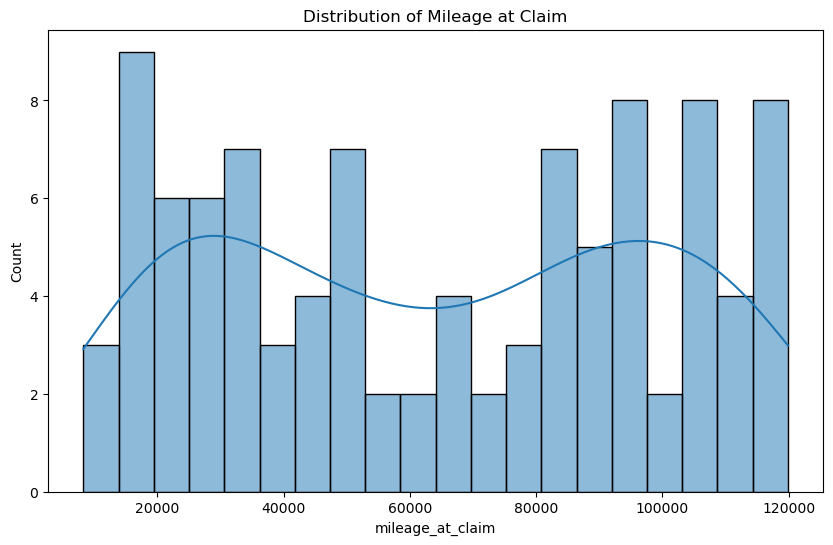

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(df['mileage_at_claim'], bins=20, kde=True)
plt.title("Distribution of Mileage at Claim")
plt.show()


### Distribution of Claim Costs by Vehicle Model

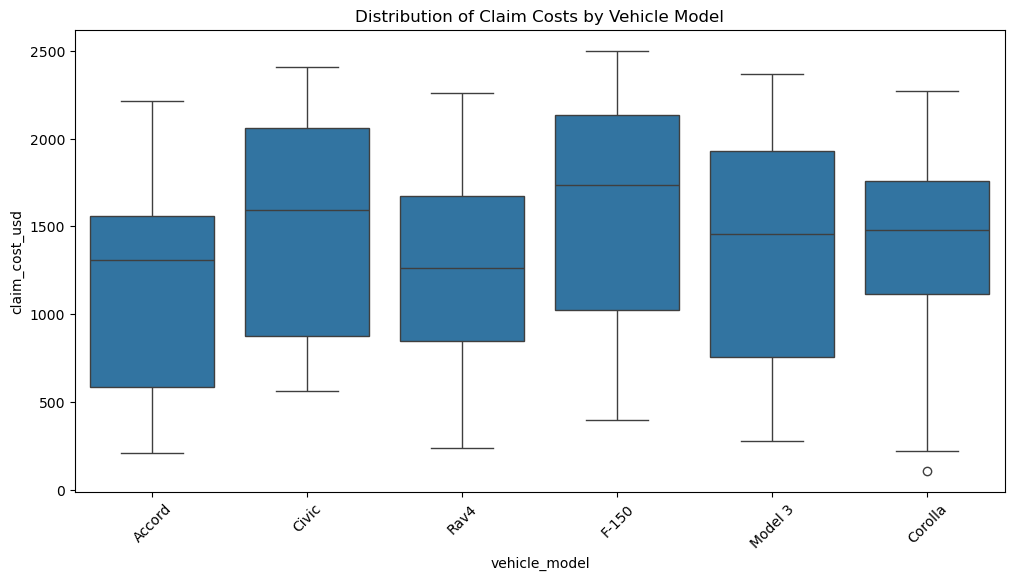

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='vehicle_model', y='claim_cost_usd', data=df)
plt.title("Distribution of Claim Costs by Vehicle Model")
plt.xticks(rotation=45)
plt.show()


### Failure Codes and Parts Replaced

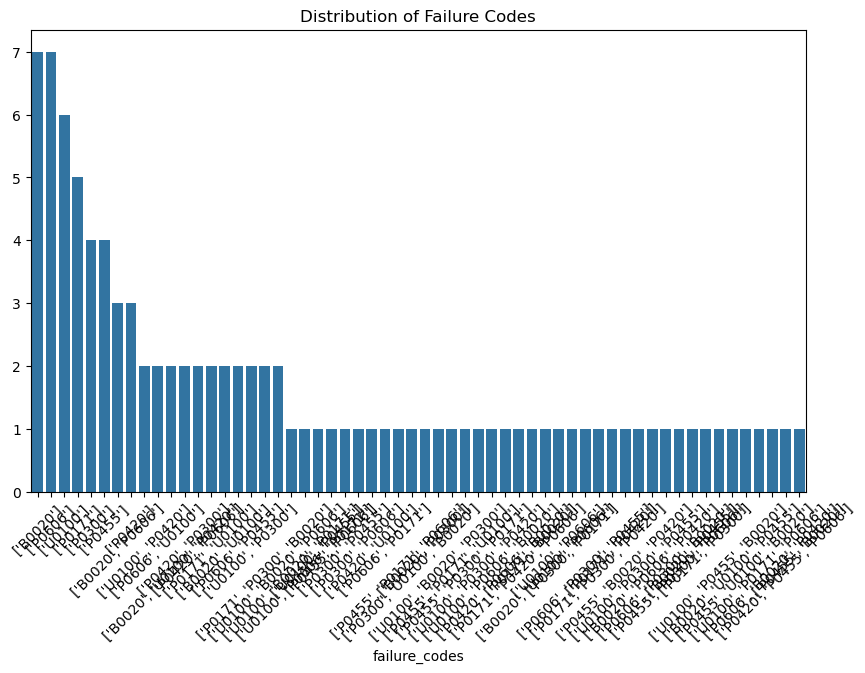

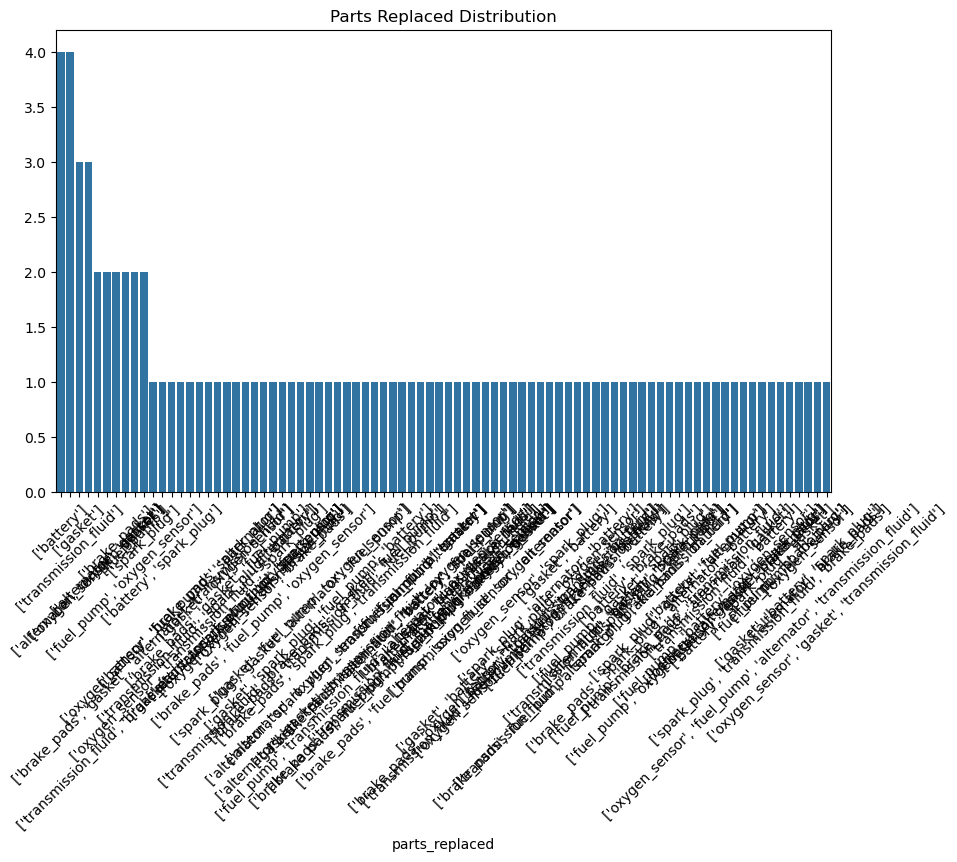

In [35]:
# Count the occurrence of failure codes
failure_codes = df['failure_codes'].explode().value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=failure_codes.index, y=failure_codes.values)
plt.title("Distribution of Failure Codes")
plt.xticks(rotation=45)
plt.show()

# Count the occurrence of parts replaced
parts_replaced = df['parts_replaced'].explode().value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=parts_replaced.index, y=parts_replaced.values)
plt.title("Parts Replaced Distribution")
plt.xticks(rotation=45)
plt.show()


# 4. FP-Growth Analysis

### Prepare Data for FP-Growth

In [132]:
import ast

# Convert stringified lists (e.g., "['sensor', 'pump']") to real Python lists
df['parts_replaced'] = df['parts_replaced'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df['parts_replaced'].head(5)

0              [oxygen_sensor, gasket]
1                          [fuel_pump]
2                [battery, brake_pads]
3    [alternator, battery, spark_plug]
4      [fuel_pump, gasket, spark_plug]
Name: parts_replaced, dtype: object

In [145]:
from collections import Counter

# Count part frequencies
all_parts = [part for sublist in df['parts_replaced'] for part in sublist]
part_counts = Counter(all_parts)

# Keep only parts that appear at least 3 times
valid_parts = {part for part, count in part_counts.items() if count >= 3}

# Filter transactions
filtered_transactions = [
    [part for part in tx if part in valid_parts]
    for tx in df['parts_replaced']
    if any(part in valid_parts for part in tx)
]
filtered_transactions

[['oxygen_sensor', 'gasket'],
 ['fuel_pump'],
 ['battery', 'brake_pads'],
 ['alternator', 'battery', 'spark_plug'],
 ['fuel_pump', 'gasket', 'spark_plug'],
 ['transmission_fluid', 'gasket', 'brake_pads'],
 ['fuel_pump', 'oxygen_sensor'],
 ['gasket'],
 ['alternator', 'oxygen_sensor'],
 ['transmission_fluid', 'spark_plug'],
 ['transmission_fluid', 'alternator', 'brake_pads', 'battery'],
 ['brake_pads', 'fuel_pump', 'spark_plug', 'transmission_fluid'],
 ['gasket', 'battery'],
 ['gasket'],
 ['brake_pads', 'gasket'],
 ['battery', 'gasket', 'transmission_fluid'],
 ['spark_plug', 'alternator', 'battery'],
 ['oxygen_sensor', 'alternator', 'transmission_fluid'],
 ['oxygen_sensor', 'spark_plug'],
 ['gasket', 'battery', 'spark_plug', 'oxygen_sensor'],
 ['transmission_fluid'],
 ['transmission_fluid', 'fuel_pump', 'oxygen_sensor', 'battery'],
 ['brake_pads', 'oxygen_sensor', 'transmission_fluid', 'battery'],
 ['brake_pads', 'spark_plug', 'alternator', 'battery'],
 ['spark_plug', 'alternator'],
 ['f

In [147]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit_transform(filtered_transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)
df_encoded

,alternator,battery,brake_pads,fuel_pump,gasket,oxygen_sensor,spark_plug,transmission_fluid
0,False,False,False,False,True,True,False,False
1,False,False,False,True,False,False,False,False
2,False,True,True,False,False,False,False,False
3,True,True,False,False,False,False,True,False
4,False,False,False,True,True,False,True,False
...,...,...,...,...,...,...,...,...
95,False,False,True,False,False,False,True,True
96,False,False,True,True,False,False,False,True
97,False,True,False,True,True,False,True,False
98,False,False,False,False,True,True,False,True


In [149]:
from mlxtend.frequent_patterns import fpgrowth

frequent_itemsets = fpgrowth(df_encoded, min_support=0.1, use_colnames=True)
frequent_itemsets.sort_values(by='support', ascending=False, inplace=True)

# Display top itemsets with real part names
print(frequent_itemsets.head(10))

    support                          itemsets
7      0.36              (transmission_fluid)
2      0.33                       (fuel_pump)
0      0.32                   (oxygen_sensor)
3      0.32                         (battery)
1      0.32                          (gasket)
5      0.31                      (spark_plug)
6      0.30                      (alternator)
4      0.29                      (brake_pads)
12     0.13  (transmission_fluid, brake_pads)
8      0.13        (oxygen_sensor, fuel_pump)


### Generate Association Rules

In [171]:
# Generate association rules based on confidence > 0.6
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.3)

# Display rules with the highest lift
rules_simple = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules_simple.sort_values(by='lift', ascending=False)


,antecedents,consequents,support,confidence,lift
0,(transmission_fluid),(brake_pads),0.13,0.361111,1.245211
1,(brake_pads),(transmission_fluid),0.13,0.448276,1.245211
2,(oxygen_sensor),(fuel_pump),0.13,0.406250,1.231061
3,(fuel_pump),(oxygen_sensor),0.13,0.393939,1.231061
6,(spark_plug),(battery),0.12,0.387097,1.209677
7,(battery),(spark_plug),0.12,0.375000,1.209677
14,(alternator),(spark_plug),0.10,0.333333,1.075269
13,(spark_plug),(alternator),0.10,0.322581,1.075269
12,(fuel_pump),(brake_pads),0.10,0.303030,1.044932
11,(brake_pads),(fuel_pump),0.10,0.344828,1.044932


### 🔍 Business Interpretation
##### Rule: {transmission_fluid} → {oxygen_sensor}
🔧 If a fuel pump is replaced, there’s a 39% chance the oxygen sensor was also replaced.

##### Rule: {brake_pads} → {transmission_fluid}
⚠️ Brake issues often coincide with transmission maintenance in 45% of cases — investigate further.

# 5. Visualize Association Rules Using NetworkX

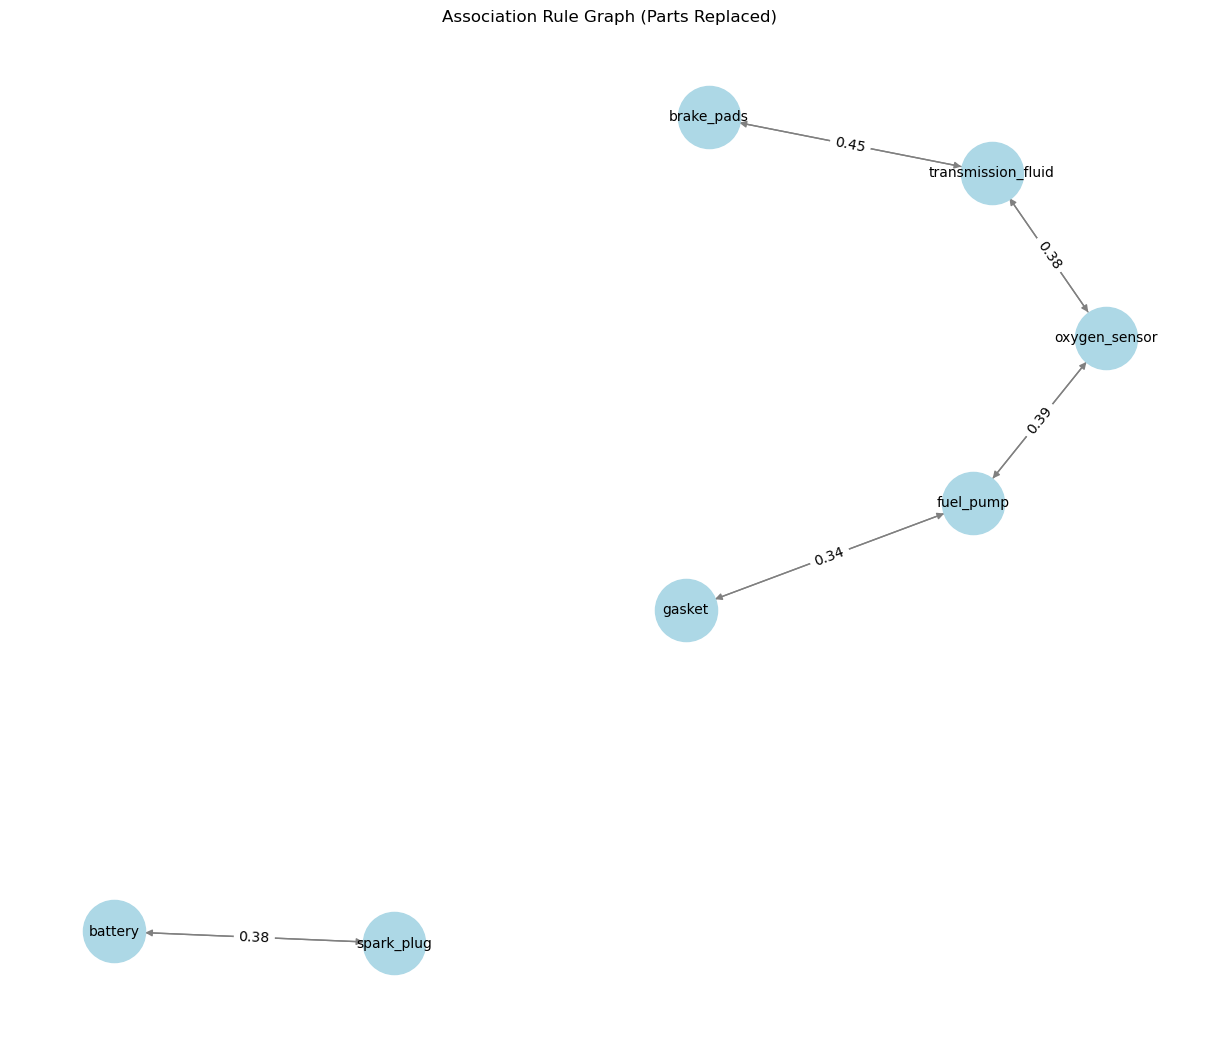

In [167]:
def draw_graph(rules_df):
    G = nx.DiGraph()
    for _, row in rules_df.iterrows():
        for ant in row['antecedents']:
            for cons in row['consequents']:
                G.add_edge(ant, cons, weight=row['confidence'])
    
    pos = nx.spring_layout(G, k=0.5, iterations=50)
    plt.figure(figsize=(12, 10))
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', edge_color='gray', font_size=10)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    edge_labels = {k: f"{v:.2f}" for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title("Association Rule Graph (Parts Replaced)")
    plt.show()

# Visualize top 10 rules
draw_graph(rules_simple.head(10))
